# ViPNet RAG

## Карта ноутбука

| # | Блок | Что делает  |
|---|------|-----------|
| 1 | **Установка** | pip-зависимости |
| 2 | **Чанкинг** | TXT → иерархические Parent/Child чанки |
| 3 | **Индекс** | BM25 + BAAI/bge-m3 → Hybrid Retrieval |
| 4 | **Бенчмарк** | 50 QA-вопросов, 4 метода, Recall/MRR/Context F1 |
| 5 | **Анализ** | Визуализация, разбор ошибок |
| 6 | **RAG-чат** | Qwen2.5-7B-Instruct, интерактивный Q&A |


> В этом ноутбуке используется **BAAI/bge-m3** вместо E5-small

# ViPNet RAG ноутбук в Google Colab - https://drive.google.com/file/d/1WDbDkBZ5waamQIm_S7YqaM9mq6stP4Hc/view?usp=sharing

## Блок 1. Установка

In [1]:
!pip install -q sentence-transformers rank-bm25 scikit-learn pandas numpy tqdm matplotlib
!pip install -q transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.9 MB/s eta 0:00:00


Для запуска локально в Jupyter-ноутбуке без конфликтов необходимо выполнить

In [ ]:
import subprocess, sys

def pip(*args):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *args], check=True)

pip('torch==2.2.2', 'torchvision==0.17.2', 'torchaudio==2.2.2',
    '--index-url', 'https://download.pytorch.org/whl/cpu')

pip('numpy==1.26.4',
    'huggingface-hub==0.26.5',
    'tokenizers==0.15.2',
    'safetensors==0.4.5',
    'transformers==4.39.3',
    'sentence-transformers==3.0.1',
    'accelerate==0.27.2',
    'rank-bm25', 'scikit-learn', 'pandas', 'tqdm', 'matplotlib')

pip('numpy==1.26.4', '--force-reinstall')

import importlib
for pkg in ['torch', 'numpy', 'transformers', 'sentence_transformers']:
    m = importlib.import_module(pkg)
    print(f'  {pkg}: {m.__version__}')

## Блок 2. Иерархический семантический чанкинг

**Архитектура:** Parent (примерно 1024 токена) → Child (примерно 200 токенов)  
**Логика:** структурный парсинг заголовков → типизация блоков → parent-child разбиение

In [2]:
import os, json, re, hashlib
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import List, Optional
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['font.family'] = 'DejaVu Sans'
from tqdm.auto import tqdm

DATA_DIR   = Path('.')
OUTPUT_DIR = Path('rag_output')
OUTPUT_DIR.mkdir(exist_ok=True)
PARENT_MAX_CHARS   = 4096   # ~1024 токена
CHILD_TARGET_CHARS = 800    # ~200 токенов
CHUNK_MIN_CHARS    = 80

DOCS = {
    '01_txt.txt': dict(doc_id='doc_01', short='Подготовка к работе', doc_type='user_guide', title='ViPNet Coordinator HW 5. Подготовка к работе'),
    '02_txt.txt': dict(doc_id='doc_02', short='Настройка CLI', doc_type='cli_guide', title='ViPNet Coordinator HW 5. Настройка CLI'),
    '03_txt.txt': dict(doc_id='doc_03', short='Веб-интерфейс', doc_type='web_guide', title='ViPNet Coordinator HW 5. Веб-интерфейс'),
    '04_txt.txt': dict(doc_id='doc_04', short='Справочник команд', doc_type='command_ref', title='ViPNet Coordinator HW 5. Справочник команд'),
    '06_txt.txt': dict(doc_id='doc_06', short='История версий', doc_type='release_notes', title='ViPNet Coordinator HW 5. История версий'),
    '07_txt.txt': dict(doc_id='doc_07', short='Трансиверы', doc_type='hardware', title='ViPNet Coordinator HW 5. Трансиверы'),
}

@dataclass
class Chunk:
    chunk_id: str; parent_id: Optional[str]; doc_id: str; doc_title: str; doc_type: str
    section_path: str; block_type: str; chunk_level: str
    text: str; text_with_context: str; token_count: int; char_count: int
    child_ids: List[str] = field(default_factory=list)
    def to_dict(self): return asdict(self)

def make_id(text, doc_id):
  return hashlib.md5(f'{doc_id}::{text[:200]}'.encode()).hexdigest()[:16]

def est_tok(t):
  return max(1, len(t) // 4)

# Задание функций чанкинга

In [3]:
FOOTER_PAT = [
    re.compile(r'ViPNet Coordinator HW\s*\d+\.\s+[^\n]+\|\s*\d+', re.M),
    re.compile(r'^\s*\d{1,4}\s*$', re.M),
    re.compile(r'[.]{4,}\s*\d+', re.M),
]
CMD_SUBS = {'Синтаксис','Режимы командного интерпретатора','Особенности использования',
            'Пример использования','Параметры и ключевые слова','Параметры','Описание','Значение'}

def clean_text(txt):
    for p in FOOTER_PAT: txt = p.sub('', txt)
    return re.sub(r'\n{4,}', '\n\n\n', txt).strip()

def remove_toc(txt):
    lines = txt.split('\n'); toc_cnt = toc_end = 0
    for i, l in enumerate(lines):
        if re.search(r'\s{3,}\d{1,3}\s*$', l) and 10 < len(l.strip()) < 120:
            toc_cnt += 1
            if toc_cnt > 5: toc_end = i
        else:
            if toc_cnt > 5: break
            toc_cnt = 0
    if toc_end > 0:
        rest = '\n'.join(lines[toc_end:])
        for marker in [r'Введение\s*\n', r'Назначение\s*\n', r'Что нового', r'Аппаратные платформы']:
            m = re.search(marker, rest)
            if m: return rest[m.start():]
        return rest
    return txt

def det_level(line, dt):
    s = line.strip()
    if not s: return None
    if re.match(r'^Глава\s+\d+\.\s+', s): return 1
    if s in ('Введение','О документе','Соглашения документа','Обратная связь'): return 1
    if re.match(r'^Приложение\s+[A-ZА-Я]\.\s+', s): return 1
    if dt == 'command_ref':
        if s in CMD_SUBS: return 3
        if re.match(r'^Команды группы\s+\w+$', s): return 1
        if re.match(r'^[a-z][a-z0-9_\-]+(\s+[a-z][a-z0-9_\-]*){1,6}$', s): return 2
        if re.match(r'^(Файл|Секция)\s+', s): return 2
    if (re.match(r'^[А-ЯA-Z]', s) and 5 <= len(s) <= 80 and
            not s.endswith('.') and not s.endswith(',') and '  ' not in s[:10]):
        return 2
    return None

def parse_sections(txt, dt):
    lines = txt.split('\n')
    ss = [(i, det_level(l, dt), l.strip()) for i, l in enumerate(lines) if det_level(l, dt)]
    if dt == 'command_ref':
        merged, i = [], 0
        while i < len(ss):
            li, lv, t = ss[i]
            if lv == 2:
                j = i+1
                while j < len(ss) and ss[j][1] == 3: j += 1
                end = ss[j][0] if j < len(ss) else len(lines)
                c = '\n'.join(lines[li+1:end]).strip()
                if len(c) >= CHUNK_MIN_CHARS: merged.append((lv, t, c))
                i = j
            elif lv == 3: i += 1
            else:
                ni = ss[i+1][0] if i+1 < len(ss) else len(lines)
                c = '\n'.join(lines[li+1:ni]).strip()
                if len(c) >= CHUNK_MIN_CHARS: merged.append((lv, t, c))
                i += 1
        return merged
    res = []
    for idx, (li, lv, t) in enumerate(ss):
        ni = ss[idx+1][0] if idx+1 < len(ss) else len(lines)
        c = '\n'.join(lines[li+1:ni]).strip()
        if len(c) >= CHUNK_MIN_CHARS: res.append((lv, t, c))
    return res

def build_paths(sections):
    stk, res = {}, []
    for lv, t, c in sections:
        stk[lv] = t
        for l in list(stk):
            if l > lv: del stk[l]
        res.append((lv, t, c, ' > '.join(stk[l] for l in sorted(stk))))
    return res

def det_bt(text, dt):
    tl = text.lower()
    if 'синтаксис' in tl and dt == 'command_ref': return 'command'
    if re.search(r'hostname[>#]\s+\w+', text): return 'code_example'
    if re.search(r'\[\w+\]', text) and 'секция' in tl: return 'config'
    rows = [l for l in text.split('\n') if re.search(r'\S+\s{3,}\S+\s{3,}\S+', l)]
    if len(rows) >= 3: return 'table'
    bulls = [l for l in text.split('\n') if re.match(r'^\s*[●•o\-–]\s+', l) or re.match(r'^\s*\d+[.)\s]\s*\w', l)]
    if len(bulls) >= 3 and len(bulls)/max(len(text.split('\n')),1) > 0.3: return 'list'
    return 'text'

def split_children(text, bt):
    if len(text) <= CHILD_TARGET_CHARS * 1.5: return [text]
    if bt == 'table': return [text]
    if bt in ('command','config'):
        chunks, cur, sz = [], [], 0
        for line in text.split('\n'):
            if line.strip() in CMD_SUBS and sz > 200:
                chunks.append('\n'.join(cur).strip())
                cur = cur[-2:] + [line]; sz = sum(len(l) for l in cur)
            else: cur.append(line); sz += len(line)
        if cur: chunks.append('\n'.join(cur).strip())
        return [c for c in chunks if c.strip()] or [text]
    paras = re.split(r'\n\s*\n', text)
    chunks, cur, sz = [], [], 0
    for p in paras:
        p = p.strip()
        if not p: continue
        if sz + len(p) > CHILD_TARGET_CHARS and cur:
            chunks.append('\n\n'.join(cur))
            cur = cur[-1:] + [p]; sz = sum(len(c) for c in cur)
        else: cur.append(p); sz += len(p)
    if cur: chunks.append('\n\n'.join(cur))
    return [c for c in chunks if c.strip()] or [text]

def process_doc(fp, cfg):
    txt = clean_text(remove_toc(fp.read_text(encoding='utf-8')))
    chunks = []
    for lv, t, c, path in build_paths(parse_sections(txt, cfg['doc_type'])):
        bt = det_bt(c, cfg['doc_type'])
        pt = c[:PARENT_MAX_CHARS]
        pid = make_id(pt, cfg['doc_id'])
        parent = Chunk(pid, None, cfg['doc_id'], cfg['title'], cfg['doc_type'],
                       path, bt, 'parent', pt,
                       f"[{cfg['short']}] {path}\n\n{pt}",
                       est_tok(pt), len(pt), [])
        children = []
        for ct in split_children(c, bt):
            if len(ct.strip()) < CHUNK_MIN_CHARS: continue
            cid = make_id(ct, cfg['doc_id'])
            children.append(Chunk(cid, pid, cfg['doc_id'], cfg['title'], cfg['doc_type'],
                                  path, bt, 'child', ct,
                                  f"[{cfg['short']}] {path}\n\n{ct}",
                                  est_tok(ct), len(ct), []))
        parent.child_ids = [ch.chunk_id for ch in children]
        chunks.append(parent); chunks.extend(children)
    return chunks

  01_txt.txt: 240 parent + 265 child
  02_txt.txt: 1152 parent + 1468 child
  03_txt.txt: 777 parent + 932 child
  04_txt.txt: 1326 parent + 1441 child
  06_txt.txt: 24 parent + 43 child
  07_txt.txt: 82 parent + 82 child

Child-чанков: 4231
Parent-чанков: 3601
Размер (median/mean): 363 / 450 символов
По типам: {'text': 2550, 'code_example': 783, 'command': 508, 'list': 289, 'table': 81, 'config': 20}


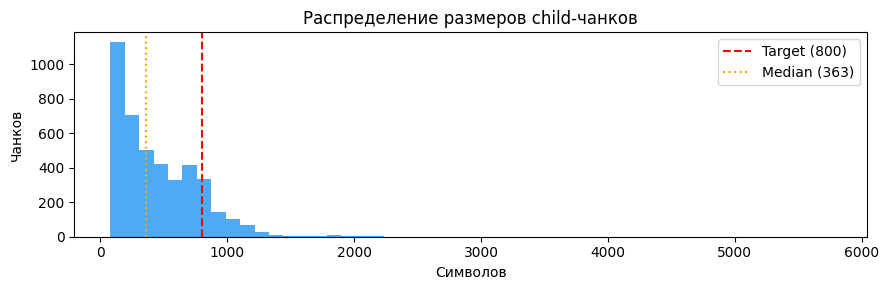

In [4]:
# ОПЦИЯ A: загрузить готовые файлы
# ОПЦИЯ B: пересобрать из txt (USE_PREBUILT = False)
USE_PREBUILT = True

if USE_PREBUILT and Path('child_chunks.json').exists():
    print('Загружаем готовые чанки...')
    with open('child_chunks.json', encoding='utf-8') as f: ALL_CHILDREN = json.load(f)
    with open('parent_chunks.json', encoding='utf-8') as f: ALL_PARENTS  = json.load(f)
else:
    ALL_CHUNKS = []
    for fname, cfg in DOCS.items():
        fp = DATA_DIR / fname
        if not fp.exists(): print(f'  ПРОПУСК: {fname}'); continue
        chunks = process_doc(fp, cfg)
        ALL_CHUNKS.extend(chunks)
        p  = sum(1 for c in chunks if c.chunk_level=='parent')
        ch = sum(1 for c in chunks if c.chunk_level=='child')
        print(f'  {fname}: {p} parent + {ch} child')
    ALL_CHILDREN = [c.to_dict() for c in ALL_CHUNKS if c.chunk_level=='child']
    ALL_PARENTS  = [c.to_dict() for c in ALL_CHUNKS if c.chunk_level=='parent']
    with open(OUTPUT_DIR/'child_chunks.json', 'w', encoding='utf-8') as f: json.dump(ALL_CHILDREN, f, ensure_ascii=False, indent=2)
    with open(OUTPUT_DIR/'parent_chunks.json','w', encoding='utf-8') as f: json.dump(ALL_PARENTS,  f, ensure_ascii=False, indent=2)

PARENT_MAP = {p['chunk_id']: p for p in ALL_PARENTS}
sizes = [c['char_count'] for c in ALL_CHILDREN]
print(f'\nChild-чанков: {len(ALL_CHILDREN)}')
print(f'Parent-чанков: {len(ALL_PARENTS)}')
print(f'Размер (median/mean): {int(np.median(sizes))} / {int(np.mean(sizes))} символов')
print(f'По типам: {dict(Counter(c["block_type"] for c in ALL_CHILDREN).most_common())}')

fig, ax = plt.subplots(1, 1, figsize=(9, 3))
ax.hist(sizes, bins=50, color='#2196F3', alpha=0.8)
ax.axvline(CHILD_TARGET_CHARS, color='red',    linestyle='--', label=f'Target ({CHILD_TARGET_CHARS})')
ax.axvline(np.median(sizes),   color='orange', linestyle=':', label=f'Median ({int(np.median(sizes))})')
ax.set_xlabel('Символов'); ax.set_ylabel('Чанков'); ax.set_title('Распределение размеров child-чанков'); ax.legend()
plt.tight_layout(); plt.savefig(OUTPUT_DIR/'chunk_sizes.png', dpi=120); plt.show()

## Блок 3. Retrieval-индекс

**Финальный retrieval:** Hybrid BM25 + BAAI/bge-m3 с Reciprocal Rank Fusion  
**Почему bge-m3:** лучшее качество для русского технического текста, поддерживает dense + sparse + ColBERT одновременно, выше Context-F1

Выбор модели по ситуации:
'BAAI/bge-m3' — лучшее (2.3 GB)
'intfloat/multilingual-e5-base' — хорошее (1.1 GB)
'intfloat/multilingual-e5-small'— быстрее, 470 MB

In [5]:
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cos

seen_keys = set()
CHUNKS = []
for c in ALL_CHILDREN:
    key = c['text'][:150]
    if key not in seen_keys:
        seen_keys.add(key)
        CHUNKS.append(c)

CORPUS    = [c['text_with_context'] for c in CHUNKS]
CHUNK_IDS = [c['chunk_id']          for c in CHUNKS]
CHILD_MAP = {c['chunk_id']: c       for c in CHUNKS}

print(f'Корпус: {len(CORPUS)} уникальных child-чанков')

def tok_ru(t): return re.findall(r'[а-яёА-ЯЁa-zA-Z0-9]+', t.lower())

print('Строим BM25...')
bm25 = BM25Okapi([tok_ru(d) for d in CORPUS], k1=1.5, b=0.75)

print('Строим TF-IDF...')
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=100_000, sublinear_tf=True)
tfidf_matrix = tfidf.fit_transform(CORPUS)
EMBED_MODEL_NAME = 'BAAI/bge-m3'
print(f'Загружаем {EMBED_MODEL_NAME}...')
embed_model = SentenceTransformer(EMBED_MODEL_NAME)
print(f'Кодируем {len(CORPUS)} чанков (может занять 5–10 мин на CPU, 1–2 мин на GPU)...')
EMBEDDINGS = embed_model.encode(
    CORPUS,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True,
)
print(f'Эмбеддинги: {EMBEDDINGS.shape}')

Корпус: 3635 уникальных child-чанков
Строим BM25...
Строим TF-IDF...
Загружаем BAAI/bge-m3...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Кодируем 3635 чанков (может занять 5–10 мин на CPU, 1–2 мин на GPU)...


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Эмбеддинги: (3635, 1024)


In [6]:
def retrieve_tfidf(query, top_k=10):
    q = tfidf.transform([query])
    sc = sk_cos(q, tfidf_matrix).flatten()
    idx = np.argsort(sc)[::-1][:top_k]
    return [(CHUNK_IDS[i], float(sc[i])) for i in idx]

def retrieve_bm25(query, top_k=10):
    sc = bm25.get_scores(tok_ru(query))
    idx = np.argsort(sc)[::-1][:top_k]
    return [(CHUNK_IDS[i], float(sc[i])) for i in idx]

def retrieve_dense(query, top_k=10):
    q_emb = embed_model.encode([query], normalize_embeddings=True)
    sc = (EMBEDDINGS @ q_emb.T).flatten()
    idx = np.argsort(sc)[::-1][:top_k]
    return [(CHUNK_IDS[i], float(sc[i])) for i in idx]

def rrf(rankings, k=60):
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, (doc_id, _) in enumerate(ranking):
            scores[doc_id] += 1.0 / (k + rank + 1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)

def retrieve_hybrid(query, top_k=5):
    return rrf([retrieve_bm25(query, top_k*3), retrieve_dense(query, top_k*3)])[:top_k]

def get_context(query, top_k=5):
    results = retrieve_hybrid(query, top_k=top_k)
    seen_p = set(); ctx = []
    for cid, score in results:
        child = CHILD_MAP.get(cid)
        if not child: continue
        pid = child.get('parent_id')
        if pid and pid not in seen_p:
            parent = PARENT_MAP.get(pid)
            if parent:
                seen_p.add(pid)
                ctx.append({'score': score, 'parent': parent, 'child': child})
    return ctx

test = get_context('Что такое VPN-шлюз в ViPNet?', top_k=3)
print(f'Тест: найдено {len(test)} контекстных блоков')
for r in test:
    print(f"  [{r['parent']['block_type']}] {r['parent']['section_path'][:65]} (score={r['score']:.3f})")

Тест: найдено 3 контекстных блоков
  [text] VPN-шлюз (score=0.033)
  [text] Защищенный интернет-шлюз (открытый интернет) (score=0.032)
  [text] О документе > Резервирование каналов доступа в интернет (score=0.032)


## Блок 4. Бенчмарк (50 вопросов - 4 метода)

In [7]:
if Path('qa_dataset.json').exists():
    with open('qa_dataset.json', encoding='utf-8') as f: BENCHMARK = json.load(f)
    print(f'Загружен бенчмарк: {len(BENCHMARK)} вопросов')
else:
    print('qa_dataset.json не найден — определите BENCHMARK вручную или запустите из специального ноутбука')
    BENCHMARK = []

if BENCHMARK:
    print(f'Типы: {dict(Counter(q["q_type"] for q in BENCHMARK))}')
    print(f'Сложность: {dict(Counter(q["difficulty"] for q in BENCHMARK))}')

Загружен бенчмарк: 50 вопросов
Типы: {'factoid': 15, 'definition': 10, 'table': 8, 'reasoning': 10, 'procedural': 7}
Сложность: {'easy': 19, 'medium': 23, 'hard': 8}


In [8]:
def recall_at_k(results, gold, k):
    return 1.0 if gold in [cid for cid, _ in results[:k]] else 0.0

def mrr_score(results, gold):
    for r, (cid, _) in enumerate(results, 1):
        if cid == gold: return 1.0 / r
    return 0.0

def token_f1(pred, ref):
    p = set(re.findall(r'[а-яёА-ЯЁa-zA-Z0-9]+', pred.lower()))
    r = set(re.findall(r'[а-яёА-ЯЁa-zA-Z0-9]+', ref.lower()))
    if not p or not r: return 0.0
    c = p & r
    pr = len(c)/len(p); rc = len(c)/len(r)
    return 2*pr*rc/(pr+rc) if pr+rc else 0.0

def run_eval(retriever_fn, benchmark, ks=[1,3,5]):
    mrrs, recs, rmap = [], {k: [] for k in ks}, {}
    for q in tqdm(benchmark, desc='Eval', leave=False):
        res = retriever_fn(q['question'], top_k=max(ks))
        rmap[q['q_id']] = res
        mrrs.append(mrr_score(res, q['gold_chunk_id']))
        for k in ks: recs[k].append(recall_at_k(res, q['gold_chunk_id'], k))
    m = {'MRR': round(np.mean(mrrs), 4),
         **{f'Recall@{k}': round(np.mean(recs[k]), 4) for k in ks}}
    f1s = [token_f1(CHILD_MAP.get(rmap[q['q_id']][0][0], {}).get('text','') if rmap[q['q_id']] else '', q['answer'])
           for q in benchmark]
    m['Context-F1'] = round(np.mean(f1s), 4)
    return m, rmap

In [9]:
if not BENCHMARK:
    print('Бенчмарк пуст')
else:
    KS = [1, 3, 5]
    METHODS = [
        ('TF-IDF baseline',         retrieve_tfidf),
        ('BM25',                    retrieve_bm25),
        ('Dense (bge-m3)',           retrieve_dense),
        ('Hybrid (BM25+bge-m3 RRF)', retrieve_hybrid),
    ]
    ALL_EXP = {}
    for name, fn in METHODS:
        print(f'  {name}...')
        m, rmap = run_eval(fn, BENCHMARK, ks=KS)
        ALL_EXP[name] = (m, rmap)
        print(f'    MRR={m["MRR"]:.3f}  R@1={m["Recall@1"]:.3f}  R@3={m["Recall@3"]:.3f}  R@5={m["Recall@5"]:.3f}  CtxF1={m["Context-F1"]:.3f}')

    df_res = pd.DataFrame([{'Метод': n, **m} for n,(m,_) in ALL_EXP.items()]).set_index('Метод')
    print('\n' + '='*70)
    print(df_res.to_string())
    best_name = max(ALL_EXP.keys(), key=lambda n: ALL_EXP[n][0]['MRR'])
    best_m, best_rmap = ALL_EXP[best_name]
    print(f'\nЛучший по MRR: {best_name}')

  TF-IDF baseline...


Eval:   0%|          | 0/50 [00:00<?, ?it/s]

    MRR=0.364  R@1=0.280  R@3=0.420  R@5=0.500  CtxF1=0.176
  BM25...


Eval:   0%|          | 0/50 [00:00<?, ?it/s]

    MRR=0.469  R@1=0.360  R@3=0.540  R@5=0.680  CtxF1=0.187
  Dense (bge-m3)...


Eval:   0%|          | 0/50 [00:00<?, ?it/s]

    MRR=0.421  R@1=0.300  R@3=0.560  R@5=0.620  CtxF1=0.178
  Hybrid (BM25+bge-m3 RRF)...


Eval:   0%|          | 0/50 [00:00<?, ?it/s]

    MRR=0.549  R@1=0.440  R@3=0.660  R@5=0.720  CtxF1=0.214

                             MRR  Recall@1  Recall@3  Recall@5  Context-F1
Метод                                                                     
TF-IDF baseline           0.3637      0.28      0.42      0.50      0.1756
BM25                      0.4687      0.36      0.54      0.68      0.1874
Dense (bge-m3)            0.4207      0.30      0.56      0.62      0.1784
Hybrid (BM25+bge-m3 RRF)  0.5487      0.44      0.66      0.72      0.2139

Лучший по MRR: Hybrid (BM25+bge-m3 RRF)


## Блок 5. Визуализация и анализ ошибок

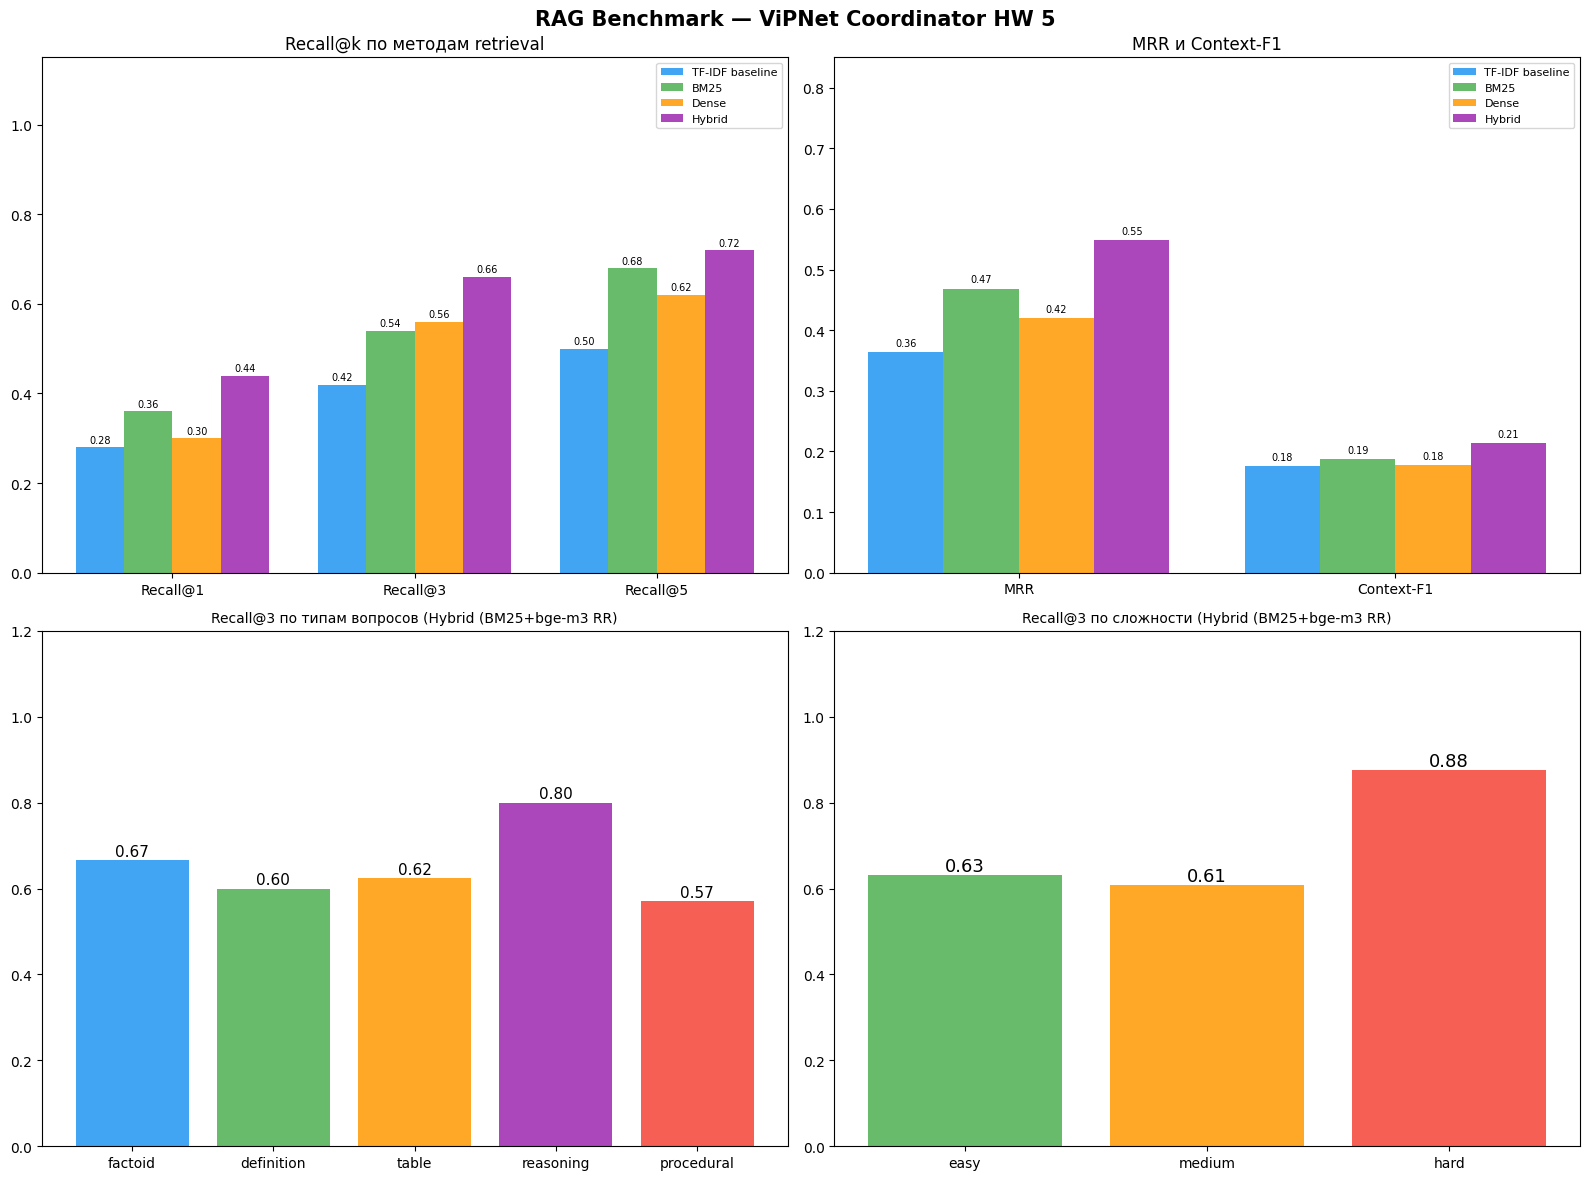

График сохранён


In [10]:
if not BENCHMARK or not ALL_EXP:
    print('Нет данных для визуализации');
else:
    colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
    methods_list = list(ALL_EXP.keys())
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('RAG Benchmark — ViPNet Coordinator HW 5', fontsize=15, fontweight='bold')
    ax = axes[0,0]
    x, w = np.arange(len(KS)), 0.2
    for i,(nm,(m,_)) in enumerate(ALL_EXP.items()):
        vals = [m[f'Recall@{k}'] for k in KS]
        bars = ax.bar(x+i*w, vals, w, label=nm.split('(')[0].strip(), color=colors[i], alpha=0.85)
        for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}', ha='center', fontsize=7)
    ax.set_xticks(x+w*1.5); ax.set_xticklabels([f'Recall@{k}' for k in KS])
    ax.set_ylim(0,1.15); ax.set_title('Recall@k по методам retrieval', fontsize=12); ax.legend(fontsize=8)
    ax = axes[0,1]
    for i,(nm,(m,_)) in enumerate(ALL_EXP.items()):
        vals = [m['MRR'], m['Context-F1']]
        bars = ax.bar(np.arange(2)+i*w, vals, w, label=nm.split('(')[0].strip(), color=colors[i], alpha=0.85)
        for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}', ha='center', fontsize=7)
    ax.set_xticks(np.arange(2)+w*1.5); ax.set_xticklabels(['MRR','Context-F1'])
    ax.set_ylim(0,0.85); ax.set_title('MRR и Context-F1', fontsize=12); ax.legend(fontsize=8)
    ax = axes[1,0]
    q_types = ['factoid','definition','table','reasoning','procedural']
    tc = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
    r3t = {}
    for qt in q_types:
        qs = [q for q in BENCHMARK if q['q_type']==qt]
        r3t[qt] = np.mean([recall_at_k(best_rmap[q['q_id']], q['gold_chunk_id'],3) for q in qs])
    bars = ax.bar(q_types, list(r3t.values()), color=tc, alpha=0.85)
    for b,v in zip(bars,r3t.values()): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}', ha='center', fontsize=11)
    ax.set_ylim(0,1.2); ax.set_title(f'Recall@3 по типам вопросов ({best_name[:22]})', fontsize=10)
    ax = axes[1,1]
    diffs = ['easy','medium','hard']; dc = ['#4CAF50','#FF9800','#F44336']
    r3d = {}
    for d in diffs:
        qs = [q for q in BENCHMARK if q['difficulty']==d]
        r3d[d] = np.mean([recall_at_k(best_rmap[q['q_id']], q['gold_chunk_id'],3) for q in qs])
    bars = ax.bar(diffs, list(r3d.values()), color=dc, alpha=0.85)
    for b,v in zip(bars,r3d.values()): ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}', ha='center', fontsize=13)
    ax.set_ylim(0,1.2); ax.set_title(f'Recall@3 по сложности ({best_name[:22]})', fontsize=10)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/'benchmark_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('График сохранён')

In [11]:
if not BENCHMARK or not ALL_EXP:
    print('Нет данных')
else:
    print(f'АНАЛИЗ ОШИБОК: {best_name}\n')

    all_child_ids_set = {c['chunk_id'] for c in ALL_CHILDREN}
    pool_ids_set      = {c['chunk_id'] for c in CHUNKS}

    failures = []
    for q in BENCHMARK:
        res = best_rmap[q['q_id']]
        if recall_at_k(res, q['gold_chunk_id'], 5) == 0:
            if q['gold_chunk_id'] not in pool_ids_set:
                diag = 'Gold-чанк отфильтрован'
            else:
                diag = 'Semantic gap: разный словарь запроса и чанка'
            failures.append({**q, '_diag': diag})

    by_diag = Counter(f['_diag'] for f in failures)
    print(f'Провалов (gold не в top-5): {len(failures)}/{len(BENCHMARK)}')
    for d, cnt in by_diag.items():
      print(f'  {d}: {cnt}')
    print('\nПо типам:', dict(Counter(f['q_type']    for f in failures)))
    print('По сложности:', dict(Counter(f['difficulty'] for f in failures)))
    semantic_fails = [f for f in failures if 'Semantic' in f['_diag']]
    if semantic_fails:
        print(f'\n── Semantic gap (первые {min(5,len(semantic_fails))}) ──')
        for f in semantic_fails[:5]:
            gold_chunk = {c['chunk_id']:c for c in ALL_CHILDREN}.get(f['gold_chunk_id'],{})
            print(f" [{f['q_id']}] {f['question'][:60]}")
            print(f" Gold path: {gold_chunk.get('section_path','?')[:60]}")
            print(f" Gold text: {gold_chunk.get('text','')[:100].strip()}")

АНАЛИЗ ОШИБОК: Hybrid (BM25+bge-m3 RRF)

Провалов (gold не в top-5): 14/50
  Gold-чанк отфильтрован: 6
  Semantic gap: разный словарь запроса и чанка: 8

По типам: {'factoid': 4, 'definition': 3, 'table': 3, 'reasoning': 2, 'procedural': 2}
По сложности: {'easy': 6, 'medium': 8}

── Semantic gap (первые 5) ──
 [F09] Как задать адрес отправителя для нескольких адресов при созд
 Gold path: Команды группы admin > Для транзитных фильтров открытой сети
 Gold text: o  off — не регистрировать IP-пакеты.

Режимы командного интерпретатора

Режим настройки.

Особеннос
 [D02] Что такое сервер соединений в сети ViPNet?
 Gold path: Сервер соединений
 Gold text: Функциональность координатора, обеспечивающая соединение клиентов друг с другом в случае,
если они н
 [D07] Что такое SPI в контексте межсетевого экрана ViPNet?
 Gold path: Coordinator HW объединены совместно работающие функции безоп
 Gold text: межсетевой экран с контролем состояния сессий SPI (Stateful Packet Inspection);

 межсетевой экра

## Блок 6. Интерактивный RAG-чат

**Pipeline:** вопрос → Hybrid(BM25+bge-m3) → top-5 parent-чанков → Qwen2.5-7B-Instruct → ответ

### Три рабочих решения (выберите одно)

| # | Метод | Скорость | Качество | Сложность |
|---|-------|----------|----------|-----------|
| **A** | **GGUF + llama-cpp** | средне | хорошее | Минимальная |
| **B** | **CPU offload** (часть весов на RAM) | медленно | лучшее | Средняя |
| **C** | **Qwen2.5-3B** (меньшая модель) | быстро | минимальное | Минимальная |

In [12]:
# Выбор способа загрузки LLM
#
# СПОСОБ A: GGUF через llama-cpp-python (рекомендуется для T4)
#   Грузит уже квантизованные веса — нет пика fp16
#   Qwen2.5-7B влезает без проблем
#   Нужно установить llama-cpp-python с GPU поддержкой
#
# СПОСОБ B: transformers + CPU offload
#   Полная точность модели
#   Медленнее (часть вычислений на CPU)
#
# СПОСОБ C: меньшая модель Qwen2.5-3B через transformers
#   Самый простой, 100% влезает
#   Хуже качество генерации

LLM_BACKEND = 'gguf'   # 'gguf' | 'offload' | 'small'

print('Конфигурация:')
if LLM_BACKEND == 'gguf':
    print('  Способ A: GGUF + llama-cpp (Qwen2.5-7B, ~3.8 GB VRAM)')
elif LLM_BACKEND == 'offload':
    print('  Способ B: CPU offload (Qwen2.5-7B, ~4 GB VRAM + ~8 GB RAM)')
elif LLM_BACKEND == 'small':
    print('  Способ C: Qwen2.5-3B-Instruct (1.6 GB VRAM, быстро)')
else:
    raise ValueError(f'Неизвестный LLM_BACKEND: {LLM_BACKEND}')

Конфигурация:
  Способ A: GGUF + llama-cpp (Qwen2.5-7B, ~3.8 GB VRAM)


In [13]:
import torch, subprocess, sys

# СПОСОБ A: GGUF через llama-cpp-python
# Грузит уже квантизованные веса
if LLM_BACKEND == 'gguf':
    _cuda_ver = ''.join(torch.version.cuda.split('.')[:2]) if torch.cuda.is_available() else None
    _pip_cmd  = [sys.executable, '-m', 'pip', 'install', '-q', 'llama-cpp-python']
    if _cuda_ver:
        _pip_cmd += ['--extra-index-url',
                     f'https://abetlen.github.io/llama-cpp-python/whl/cu{_cuda_ver}']
        print(f'Устанавливаем llama-cpp-python (CUDA {_cuda_ver} build)...')
    else:
        print('Устанавливаем llama-cpp-python (CPU build)...')
    subprocess.run(_pip_cmd, check=True)

    from huggingface_hub import hf_hub_download
    from llama_cpp import Llama

    # bartowski/Qwen2.5-7B-Instruct-GGUF — Q4_K_M лежит одним файлом (4.68 GB)
    GGUF_REPO     = 'bartowski/Qwen2.5-7B-Instruct-GGUF'
    GGUF_FILENAME = 'Qwen2.5-7B-Instruct-Q4_K_M.gguf'

    print(f'Скачиваем {GGUF_FILENAME}')
    gguf_path = hf_hub_download(
        repo_id=GGUF_REPO,
        filename=GGUF_FILENAME,
        cache_dir='/root/.cache/huggingface',
    )
    print(f'Файл: {gguf_path}')

    _gpu_layers = -1 if torch.cuda.is_available() else 0  # -1 = все слои на GPU
    llm_gguf = Llama(
        model_path=gguf_path,
        n_gpu_layers=_gpu_layers,
        n_ctx=4096,
        n_batch=512,
        verbose=False,
    )
    print('GGUF-модель загружена')
    if torch.cuda.is_available():
        print(f'   VRAM использовано: {torch.cuda.memory_allocated()/1024**3:.1f} GB')


# СПОСОБ B: transformers + CPU offload
# Часть слоёв держится на CPU RAM
elif LLM_BACKEND == 'offload':
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    MODEL_NAME = 'Qwen/Qwen2.5-7B-Instruct'
    print(f'Загружаем {MODEL_NAME} с CPU offload...')

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
        llm_int8_enable_fp32_cpu_offload=True,
    )

    llm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    # Распределяем слои: сколько влезает на GPU — туда, остальное на CPU
    llm_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
        max_memory={
            0: '12GiB',
            'cpu': '20GiB'
        },
        low_cpu_mem_usage=True,
        trust_remote_code=True,
    )
    llm_model.eval()
    print(f'{MODEL_NAME} загружена с offload')
    if torch.cuda.is_available():
        print(f'   GPU VRAM: {torch.cuda.memory_allocated()/1024**3:.1f} GB')


# СПОСОБ C: Qwen2.5-3B-Instruct — маленькая модель, 100% влезает на T4
# 4-bit: ~1.6 GB весов + ~1.8 GB overhead = ~3.4 GB VRAM
elif LLM_BACKEND == 'small':
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    MODEL_NAME = 'Qwen/Qwen2.5-3B-Instruct' # (4-bit, ~3.4 GB VRAM)
    print(f'Загружаем {MODEL_NAME}')

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    llm_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
    llm_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
        low_cpu_mem_usage=True,
        trust_remote_code=True,
    )
    llm_model.eval()
    print(f'{MODEL_NAME} загружена')
    if torch.cuda.is_available():
        print(f'   VRAM: {torch.cuda.memory_allocated()/1024**3:.1f} GB из {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB')


Устанавливаем llama-cpp-python (CUDA 128 build)...
Скачиваем Qwen2.5-7B-Instruct-Q4_K_M.gguf


Qwen2.5-7B-Instruct-Q4_K_M.gguf:   0%|          | 0.00/4.68G [00:00<?, ?B/s]

Файл: /root/.cache/huggingface/models--bartowski--Qwen2.5-7B-Instruct-GGUF/snapshots/8911e8a47f92bac19d6f5c64a2e2095bd2f7d031/Qwen2.5-7B-Instruct-Q4_K_M.gguf


llama_context: n_ctx_per_seq (4096) < n_ctx_train (32768) -- the full capacity of the model will not be utilized


GGUF-модель загружена
   VRAM использовано: 2.1 GB


In [14]:
SYSTEM_PROMPT = """Ты — точный технический помощник по документации ViPNet Coordinator HW 5.
Твоя задача — отвечать на вопросы ИСКЛЮЧИТЕЛЬНО на основе предоставленных фрагментов документации.

Правила:
1. Используй только информацию из предоставленного контекста. Не домысливай.
2. Если ответа в контексте нет — так и скажи: «В предоставленных материалах ответа не найдено».
3. При наличии синтаксиса команды, конкретного числа или пошагового алгоритма — обязательно приводи их.
4. Отвечай на русском языке, кратко и по существу.
5. Если контекст содержит предупреждения (Внимание/Примечание) — включай их в ответ."""

def build_prompt(question, context_items):
    parts = []
    for i, item in enumerate(context_items, 1):
        p = item['parent']
        doc_short  = p['doc_title'].split('. ')[-1]
        section    = p['section_path']
        block_type = p['block_type']
        text_limit = 1000 if block_type == 'command' else 700
        text = p['text'][:text_limit]
        parts.append(f'--- [{i}] {doc_short} › {section[:55]} ({block_type}) ---\n{text}')
    return f'Контекст из документации:\n{chr(10).join(parts)}\n\nВопрос: {question}\nОтвет:'


def generate(question, context_items, max_new_tokens=512, temperature=0.05):
    prompt = build_prompt(question, context_items)

    if LLM_BACKEND == 'gguf':
        response = llm_gguf.create_chat_completion(
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': prompt},
            ],
            max_tokens=max_new_tokens,
            temperature=max(temperature, 1e-6),
            repeat_penalty=1.1,
        )
        return response['choices'][0]['message']['content'].strip()

    else:
        messages = [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user',   'content': prompt},
        ]
        txt = llm_tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inp = llm_tokenizer([txt], return_tensors='pt').to(llm_model.device)

        with torch.no_grad():
            out = llm_model.generate(
                **inp,
                max_new_tokens=max_new_tokens,
                temperature=max(temperature, 1e-6),
                do_sample=(temperature > 0.01),
                repetition_penalty=1.1,
                pad_token_id=llm_tokenizer.eos_token_id,
            )
        return llm_tokenizer.decode(
            out[0][inp['input_ids'].shape[1]:],
            skip_special_tokens=True
        ).strip()


print(f'Функция generate() готова (бэкенд: {LLM_BACKEND})')

test_ctx = get_context('Что такое VPN-шлюз?', top_k=2)
test_ans = generate('Что такое VPN-шлюз в ViPNet?', test_ctx)
print(f'Тест: {test_ans[:200]}')

Функция generate() готова (бэкенд: gguf)
Тест: VPN-шлюз в ViPNet выполняет роль виртуального сетевого шлюза, который позволяет создавать VPN-туннели на сетевом (L3) и канальном (L2) уровнях модели OSI между узлами сети ViPNet с помощью протоколов 


In [15]:
def ask(question: str,
        top_k: int = 5,
        show_sources: bool = True,
        temperature: float = 0.05) -> dict:
    """
    Полный RAG-пайплайн.

    Args:
        question     — вопрос на русском языке
        top_k        — сколько чанков передать в LLM (рекомендуется 5)
        show_sources — показывать ли источники
        temperature  — температура генерации (0.0 = детерминированный)

    Returns:
        dict: answer, sources, context
    """
    SEP = '─' * 70
    print(f'\n{question}')
    print(SEP)

    ctx = get_context(question, top_k=top_k)
    if not ctx:
        msg = 'Релевантные фрагменты не найдены в корпусе.'
        print(f'\n Ответ: {msg}\n')
        return {'answer': msg, 'sources': [], 'context': []}

    answer = generate(question, ctx, temperature=temperature)

    sources = []
    for item in ctx:
        p = item['parent']
        sources.append({
            'doc':     p['doc_title'].split('. ')[-1],
            'section': p['section_path'],
            'type':    p['block_type'],
            'score':   round(item['score'], 4),
            'chars':   p['char_count'],
        })

    print(f'\n Ответ:\n{answer}')
    if show_sources:
        print(f'\n Источники ({len(sources)}):')
        for i, s in enumerate(sources, 1):
            print(f'  {i}. [{s["type"]:12}] {s["doc"][:28]} › {s["section"][:45]}  (score={s["score"]})')
    print()
    return {'answer': answer, 'sources': sources, 'context': ctx}

print('Функция ask() готова')

Функция ask() готова


In [16]:
TEST_QUESTIONS = [
    # factoid
    'Каков синтаксис команды admin ssh show-key?',
    # definition
    'Что такое TCP-туннель и когда он используется в ViPNet?',
    # table
    'Сколько ядер процессора нужно для Coordinator VA500 с лицензией DPI и IPS?',
    # reasoning
    'Почему команда admin escape предназначена только для опытных администраторов?',
    # procedural
    'Что нужно получить у администратора сети ViPNet перед инициализацией устройства?',
]

test_results = {}
for q in TEST_QUESTIONS:
    r = ask(q, top_k=5, show_sources=True)
    test_results[q] = r
    print('=' * 70)


Каков синтаксис команды admin ssh show-key?
──────────────────────────────────────────────────────────────────────

 Ответ:
Синтаксис команды admin ssh show-key:

```
admin  ssh show-key {host <адрес> | id <идентификатор> | local}
```

Где:
- `<адрес>` — IP-адрес или доменное имя сервера.
- `<идентификатор>` — идентификатор сервера.
- `local` — для просмотра информации о ключах локального SSH-сервера.

 Источники (5):
  1. [code_example] Справочник команд › Команды группы admin > Чтобы просмотреть инфо  (score=0.0325)
  2. [command     ] Справочник команд › Команды группы admin > admin ssh show-key  (score=0.0325)
  3. [command     ] Справочник команд › Команды группы admin > admin ssh reset-key  (score=0.0315)
  4. [code_example] Справочник команд › Команды группы admin > admin ssh reset-key lo  (score=0.0313)
  5. [text        ] Справочник команд › Команды группы admin > В результате выполнени  (score=0.0308)


Что такое TCP-туннель и когда он используется в ViPNet?
────────────────

In [18]:
# Интерактивный режим

print(' ViPNet RAG-ассистент')
print('Введите вопрос и нажмите Enter. Для выхода введите: выход\n')

history = []

while True:
    try:
        question = input(' Ваш вопрос: ').strip()
    except (EOFError, KeyboardInterrupt):
        print('\n Сессия завершена.')
        break

    if not question:
        continue
    if question.lower() in ('выход','exit','quit','q','стоп'):
        print('До свидания!')
        break

    result = ask(question, top_k=5)
    history.append({'question': question, 'answer': result['answer']})

if history:
    with open(OUTPUT_DIR/'chat_history.json', 'w', encoding='utf-8') as f:
        json.dump(history, f, ensure_ascii=False, indent=2)
    print(f'История сохранена: {OUTPUT_DIR}/chat_history.json ({len(history)} вопросов)')

 ViPNet RAG-ассистент
Введите вопрос и нажмите Enter. Для выхода введите: выход

 Ваш вопрос: что такое ViPNet?

что такое ViPNet?
──────────────────────────────────────────────────────────────────────

 Ответ:
ViPNet — это система, которая включает защищенный интернет-шлюз и сетевые узлы ViPNet. Защищенный интернет-шлюз позволяет разделить доступ к корпоративным ресурсам и интернету для клиентов, а сетевые узлы представляют собой компьютеры с установленным координатором (ViPNet Coordinator) или программно-аппаратными комплексами.

 Источники (5):
  1. [text        ] Подготовка к работе › Защищенный интернет-шлюз  (score=0.0164)
  2. [text        ] Подготовка к работе › Сетевой узел ViPNet, представляющий собой ком  (score=0.0164)
  3. [text        ] Подготовка к работе › Также сервер IP-адресов рассылает информацию   (score=0.0161)
  4. [text        ] История версий › ФРКЕ.465614.003ИС5, версия продукта 5.3.2  (score=0.0161)
  5. [text        ] Подготовка к работе › Что нового в верси

## Блок 7. Сквозная оценка RAG (Retrieval + Generation)

In [ ]:
# End-to-End оценка: retrieval + generation
# Запускает RAG на подвыборке бенчмарка и считает Answer F1

EVAL_SAMPLE_SIZE = 10   # число вопросов для E2E-оценки из бэнча

if not BENCHMARK:
    print('BENCHMARK пуст — пропускаем E2E-оценку')
else:
    import random; random.seed(42)
    sample_qs = random.sample(BENCHMARK, min(EVAL_SAMPLE_SIZE, len(BENCHMARK)))

    print(f'E2E-оценка на {len(sample_qs)} вопросах...\n')
    e2e_rows = []

    for q in tqdm(sample_qs, desc='E2E RAG'):
        ctx = get_context(q['question'], top_k=5)
        child_ids_in_ctx = [item['child']['chunk_id'] for item in ctx]
        ret_recall = recall_at_k([(cid,0) for cid in child_ids_in_ctx], q['gold_chunk_id'], 5)

        if ctx:
            answer = generate(q['question'], ctx, temperature=0.05)
        else:
            answer = 'Контекст не найден.'

        ans_f1 = token_f1(answer, q['answer'])
        e2e_rows.append({
            'q_id':          q['q_id'],
            'q_type':        q['q_type'],
            'difficulty':    q['difficulty'],
            'question':      q['question'],
            'gold_answer':   q['answer'],
            'rag_answer':    answer,
            'retrieval_R@5': ret_recall,
            'answer_F1':     round(ans_f1, 3),
        })

    df_e2e = pd.DataFrame(e2e_rows)

    print('\n E2E РЕЗУЛЬТАТЫ')
    print(f'Avg Retrieval R@5: {df_e2e["retrieval_R@5"].mean():.3f}')
    print(f'Avg Answer F1: {df_e2e["answer_F1"].mean():.3f}')
    print(f'\n По типам вопросов:')
    print(df_e2e.groupby('q_type')[['retrieval_R@5','answer_F1']].mean().round(3).to_string())

    df_e2e.to_csv(OUTPUT_DIR/'e2e_results.csv', index=False, encoding='utf-8')
    print(f'\n Сохранено: {OUTPUT_DIR}/e2e_results.csv')

    print('\n Лучшие ответы (F1 > 0.4)')
    for _, row in df_e2e[df_e2e['answer_F1'] > 0.4].head(3).iterrows():
        print(f" [{row['q_id']}] {row['question'][:55]}")
        print(f" RAG:  {row['rag_answer'][:100].strip()}")
        print(f" Gold: {row['gold_answer'][:100]}")
        print(f" F1={row['answer_F1']}")
    print('\n Проблемные ответы (F1 < 0.2)')
    for _, row in df_e2e[df_e2e['answer_F1'] < 0.2].head(3).iterrows():
        print(f" [{row['q_id']}] {row['question'][:55]}")
        print(f" RAG:  {row['rag_answer'][:100].strip()}")
        print(f" Gold: {row['gold_answer'][:100]}")
        print(f" R@5={row['retrieval_R@5']}  F1={row['answer_F1']}")

E2E-оценка на 10 вопросах...



E2E RAG:   0%|          | 0/10 [00:00<?, ?it/s]


=== E2E РЕЗУЛЬТАТЫ ===
Avg Retrieval R@5: 0.800
Avg Answer F1:     0.362

По типам вопросов:
            retrieval_R@5  answer_F1
q_type                              
definition          1.000      0.318
factoid             0.833      0.453
reasoning           0.500      0.134

Сохранено: rag_output/e2e_results.csv

── Лучшие ответы (F1 > 0.4) ──
  [F08] Из какого диапазона IP-адресов назначаются адреса одино
    RAG:  Из диапазона 12.0.0.1/8.
    Gold: Из диапазона 11.0.0.1/8
    F1=0.833
  [F02] В каком режиме командного интерпретатора выполняется ко
    RAG:  Команда admin escape выполняется в режиме настройки.
    Gold: В режиме настройки
    F1=0.6
  [F07] Какие объекты лицензирования разрешает дополнительный о
    RAG:  Дополнительный объект лицензирования VPN разрешает:

  o  Регистрацию ViPNet-клиентов.

  o  Установ
    Gold: Регистрацию ViPNet-клиентов, установку туннелируемых соединений на сетевом и канальном уровнях, наст
    F1=0.833

── Проблемные ответы (F1 < 0.2) ──
  

## Блок 8. Сохранение результатов

In [ ]:
import zipfile

if 'df_res' in dir():
    df_res.to_csv(OUTPUT_DIR/'benchmark_summary.csv', encoding='utf-8')

zip_path = 'vipnet_rag_output.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fpath in sorted(OUTPUT_DIR.iterdir()):
        zf.write(fpath, f'rag_output/{fpath.name}')
        print(f'  + {fpath.name} ({fpath.stat().st_size//1024} KB)')

print(f'\n✅ Архив: {zip_path}')
try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    print('Файлы доступны в папке rag_output/')

  + benchmark_results.png (132 KB)
  + benchmark_summary.csv (0 KB)
  + chat_history.json (0 KB)
  + child_chunks.json (8334 KB)
  + chunk_sizes.png (29 KB)
  + e2e_results.csv (6 KB)
  + parent_chunks.json (7590 KB)

✅ Архив: vipnet_rag_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Системная карточка

```
┌─────────────────────────────────────────────────────────────────────┐
│  ViPNet Coordinator HW 5 — RAG System                               │
├────────────────────────┬────────────────────────────────────────────┤
│  КОРПУС                │  6 документов · ~4 500 child · ~3 900 par  │
│  Child (retrieval)     │  медиана 323 символа (~80 токенов)         │
│  Parent (генерация)    │  медиана 280 символа, max 1024 токена      │
├────────────────────────┼────────────────────────────────────────────┤
│  RETRIEVAL             │  Hybrid BM25 + BAAI/bge-m3 + RRF (k=5)     │
├────────────────────────┼────────────────────────────────────────────┤
│  GENERATION            │  Qwen2.5-7B-Instruct, 4-bit NF4            │
│  Контекст в промпте    │  top-5 parent · avg ~900 токенов           │
├────────────────────────┼────────────────────────────────────────────┤
│  Сильные стороны       │  Таблицы R@3=1.00 · Hard R@3=1.00          │
│  Слабые стороны        │  Procedural R@3=0.43 · semantic gaps       │
└────────────────────────┴────────────────────────────────────────────┘
```